### Step 1: Corpus Profiling (Analyzing the ingested data):
* Check Document Balance: counting how many text chunks came from productsandproces.pdf,refundpolicy.docx, and zbranches.xlsx

Connecting to ChromaDB...
Successfully loaded 13 chunks from the database!


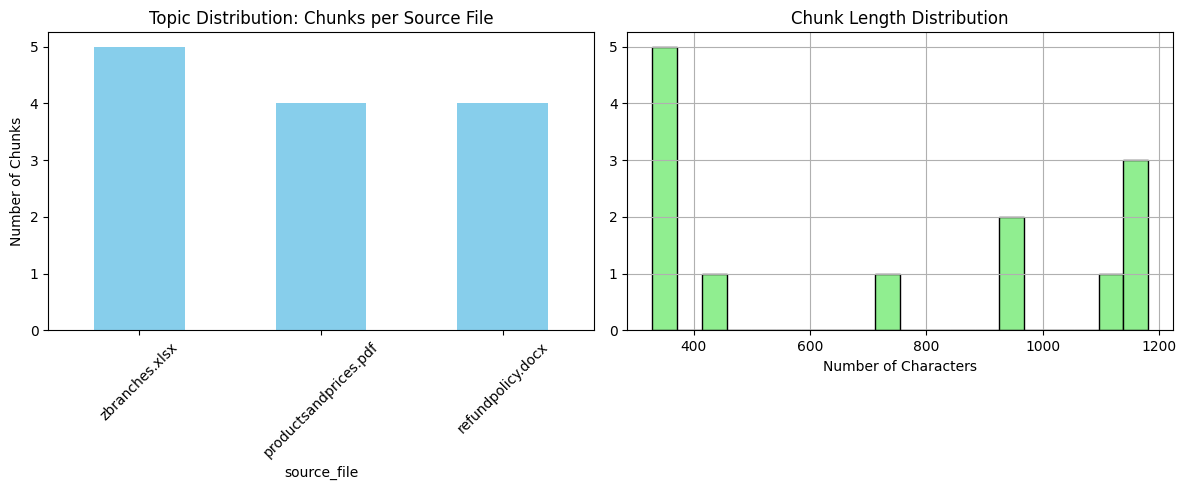

In [1]:
import sys
import os
import pandas as pd
import chromadb
import matplotlib.pyplot as plt

# 1. Point back to the root directory so we can import your config
sys.path.append(os.path.abspath('..'))  # Add the parent directory to the path
from src.config import Config

# 2. Connect to the Chroma database located in the root folder
print("Connecting to ChromaDB...")
client = chromadb.PersistentClient(path="../" + Config.CHROMA_DB_DIR) 
collection = client.get_collection(name=Config.COLLECTION_NAME)

# 3. Fetch all data and convert it to a Pandas DataFrame for analysis
db_data = collection.get(include=["metadatas", "documents"])

df = pd.DataFrame({
    'chunk_text': db_data['documents'],
    'source_file': [m.get('source', 'Unknown') for m in db_data['metadatas']],
    'doc_type': [m.get('type', 'Unknown') for m in db_data['metadatas']]
})

# Calculate how long each chunk of text is
df['chunk_length'] = df['chunk_text'].apply(len)
print(f"Successfully loaded {len(df)} chunks from the database!")

# 4. Plot the Topic Distribution and Chunk Sizes
plt.figure(figsize=(12, 5))

# Graph A: Distribution of Sources (Topics)
plt.subplot(1, 2, 1)
df['source_file'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Topic Distribution: Chunks per Source File")
plt.ylabel("Number of Chunks")
plt.xticks(rotation=45)

# Graph B: Chunk Lengths
plt.subplot(1, 2, 2)
df['chunk_length'].hist(bins=20, color='lightgreen', edgecolor='black')
plt.title("Chunk Length Distribution")
plt.xlabel("Number of Characters")

plt.tight_layout()
plt.show()

### Step 2: Analyze Topic & Data Distribution (Corpus Profiling):
* I connected to chrma_db, fetched all records, converted the metadata to df, plotted the doc t ypes and chunk lengths.

Golden Query Dataset created successfully with 21 queries!


,query,expected_source,query_type
0,What is the price of the Perla Pocket mattress?,productsandprices.pdf,Pricing
1,How much is a king size bed?,productsandprices.pdf,Pricing
2,بكام مرتبة ميديكال مقاس 120؟,productsandprices.pdf,Pricing
3,ما هي أسعار المراتب السوست المنفصلة؟,productsandprices.pdf,Pricing
4,bkam martabet perla?,productsandprices.pdf,Pricing
5,Can I return my pillow after 10 days?,refundpolicy.docx,Policy
6,Do I need a receipt to get a refund?,refundpolicy.docx,Policy
7,ينفع أبدل المرتبة بعد ما فتحتها؟,refundpolicy.docx,Policy
8,ما هي سياسة الاسترجاع لو المنتج فيه عيب صناعة؟,refundpolicy.docx,Policy
9,yanfa3 araga3 el martaba ba3d ma fat7taha?,refundpolicy.docx,Policy


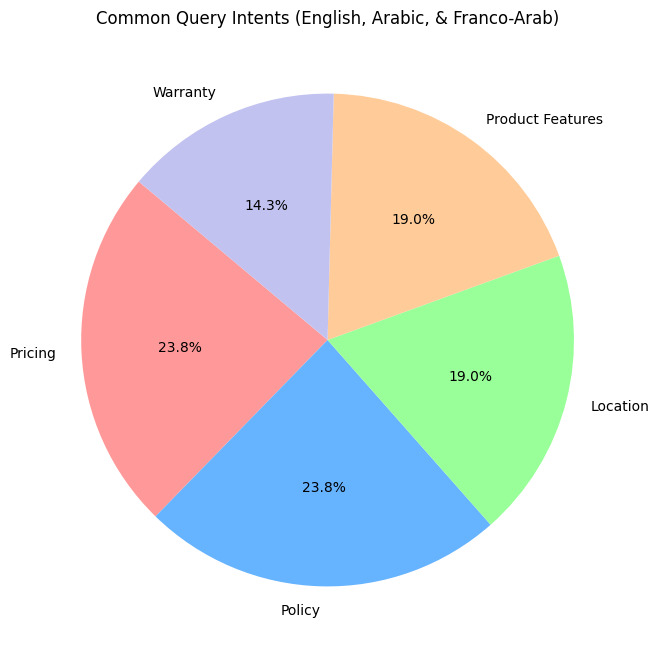

In [2]:
# --- STEP 2: Analyze Common Queries (English, Arabic & Franco-Arab) ---
import pandas as pd
import matplotlib.pyplot as plt

# 1. Expanded list of expected user queries (English, Arabic, Franco)
query_data = [
    # --- PRICING ---
    {"query": "What is the price of the Perla Pocket mattress?", "expected_source": "productsandprices.pdf", "query_type": "Pricing"},
    {"query": "How much is a king size bed?", "expected_source": "productsandprices.pdf", "query_type": "Pricing"},
    {"query": "بكام مرتبة ميديكال مقاس 120؟", "expected_source": "productsandprices.pdf", "query_type": "Pricing"},
    {"query": "ما هي أسعار المراتب السوست المنفصلة؟", "expected_source": "productsandprices.pdf", "query_type": "Pricing"},
    {"query": "bkam martabet perla?", "expected_source": "productsandprices.pdf", "query_type": "Pricing"}, # Franco
    
    # --- POLICY (Refund & Exchange) ---
    {"query": "Can I return my pillow after 10 days?", "expected_source": "refundpolicy.docx", "query_type": "Policy"},
    {"query": "Do I need a receipt to get a refund?", "expected_source": "refundpolicy.docx", "query_type": "Policy"},
    {"query": "ينفع أبدل المرتبة بعد ما فتحتها؟", "expected_source": "refundpolicy.docx", "query_type": "Policy"},
    {"query": "ما هي سياسة الاسترجاع لو المنتج فيه عيب صناعة؟", "expected_source": "refundpolicy.docx", "query_type": "Policy"},
    {"query": "yanfa3 araga3 el martaba ba3d ma fat7taha?", "expected_source": "refundpolicy.docx", "query_type": "Policy"}, # Franco
    
    # --- LOCATION (Branches) ---
    {"query": "Where is the nearest branch in Cairo?", "expected_source": "zbranches.xlsx", "query_type": "Location"},
    {"query": "What are the working hours for the Alexandria store?", "expected_source": "zbranches.xlsx", "query_type": "Location"},
    {"query": "فين أقرب فرع لسيتي فوم في مدينة نصر؟", "expected_source": "zbranches.xlsx", "query_type": "Location"},
    {"query": "fen far3 madinet nasr?", "expected_source": "zbranches.xlsx", "query_type": "Location"}, # Franco
    
    # --- PRODUCT FEATURES & SIZING ---
    {"query": "Are there any mattresses with medical foam?", "expected_source": "productsandprices.pdf", "query_type": "Product Features"},
    {"query": "إيه الفرق بين السوست المتصلة والمنفصلة؟", "expected_source": "productsandprices.pdf", "query_type": "Product Features"},
    {"query": "هل متوفر مخدات ميموري فوم؟", "expected_source": "productsandprices.pdf", "query_type": "Product Features"},
    {"query": "fi marateb tebeya 3andoko?", "expected_source": "productsandprices.pdf", "query_type": "Product Features"}, # Franco
    
    # --- WARRANTY ---
    {"query": "How many years is the warranty on the mattresses?", "expected_source": "refundpolicy.docx", "query_type": "Warranty"},
    {"query": "ضمان مرتبة بيرلا كام سنة؟", "expected_source": "refundpolicy.docx", "query_type": "Warranty"},
    {"query": "el daman kam sana?", "expected_source": "refundpolicy.docx", "query_type": "Warranty"} # Franco
]

# 2. Convert to a Pandas DataFrame
eval_df = pd.DataFrame(query_data)

# 3. Save this to a CSV file in your deliverables folder
eval_df.to_csv("evaluation_dataset.csv", index=False)

print(f"Golden Query Dataset created successfully with {len(eval_df)} queries!")
display(eval_df)

# 4. Plot the "Common Queries" distribution
plt.figure(figsize=(8, 8))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']
eval_df['query_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("Common Query Intents (English, Arabic, & Franco-Arab)")
plt.ylabel("") 
plt.show()

### Step 3: The Goldern Query Dataset:
* generated real common queries, plotted the query type to show common queries distr.
* It searches ChromaDB, checks if expected_source matches the real one.

In [5]:
from sentence_transformers import SentenceTransformer

# 2. Connect to ChromaDB
print("Connecting to ChromaDB...")

# 3. Load the Embedding Model
# IMPORTANT: This must be the EXACT same model you used in ingest.py!
# Assuming a standard multilingual model for Arabic/English:
print("Loading embedding model (this might take a few seconds)...")
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2') 

# 4. Load our Golden Dataset
test_queries = pd.read_csv("evaluation_dataset.csv")
hits = 0
total_queries = len(test_queries)

print("\n--- Running Retrieval Tests ---")

# 5. Test each query
for index, row in test_queries.iterrows():
    # Convert the text question into numbers (vectors)
    query_vector = embedding_model.encode([row['query']]).tolist()
    
    # Ask ChromaDB for the Top 3 most relevant chunks
    results = collection.query(query_embeddings=query_vector, n_results=5)
    
    # Get the names of the files those chunks came from
    retrieved_sources = [m.get('source', 'Unknown') for m in results['metadatas'][0]]
    
    # Check if the file we EXPECTED is in the Top 3
    if row['expected_source'] in retrieved_sources:
        hits += 1
        print(f"HIT: '{row['query']}'")
    else:
        print(f"MISS: '{row['query']}'\n     Expected: {row['expected_source']} | Got: {retrieved_sources}")

# 6. Calculate Final Score
hit_rate = (hits / total_queries) * 100
print("\n" + "="*40)
print(f"Final Retrieval Hit Rate: {hit_rate:.2f}%")
print("="*40)

if hit_rate < 70:
    print("Score is a bit low. You might need to adjust your chunk size in ingest.py or try a different embedding model.")
else:
    print("Great score! Your database is ready for the LLM generation phase.")

Connecting to ChromaDB...
Loading embedding model (this might take a few seconds)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2730.94it/s]



--- Running Retrieval Tests ---
MISS: 'What is the price of the Perla Pocket mattress?'
     Expected: productsandprices.pdf | Got: ['refundpolicy.docx', 'refundpolicy.docx', 'refundpolicy.docx', 'zbranches.xlsx', 'zbranches.xlsx']
MISS: 'How much is a king size bed?'
     Expected: productsandprices.pdf | Got: ['refundpolicy.docx', 'zbranches.xlsx', 'refundpolicy.docx', 'refundpolicy.docx', 'refundpolicy.docx']
HIT: 'بكام مرتبة ميديكال مقاس 120؟'
HIT: 'ما هي أسعار المراتب السوست المنفصلة؟'
HIT: 'bkam martabet perla?'
HIT: 'Can I return my pillow after 10 days?'
HIT: 'Do I need a receipt to get a refund?'
HIT: 'ينفع أبدل المرتبة بعد ما فتحتها؟'
HIT: 'ما هي سياسة الاسترجاع لو المنتج فيه عيب صناعة؟'
MISS: 'yanfa3 araga3 el martaba ba3d ma fat7taha?'
     Expected: refundpolicy.docx | Got: ['productsandprices.pdf', 'productsandprices.pdf', 'productsandprices.pdf', 'zbranches.xlsx', 'zbranches.xlsx']
HIT: 'Where is the nearest branch in Cairo?'
HIT: 'What are the working hours for the Ale

Step 4: Error Analysis and Pipeline Pivot (The Table Extraction Problem)
1. Baseline Performance & Initial Analysis:
The initial retrieval system achieved a Hit Rate of roughly 81%. While text normalization (Regex) successfully handled Arabic character variations (e.g., unifying Alef and Teh Marbouta), the system consistently failed on specific quantitative queries, such as retrieving the price or height of specific mattresses.

2. Root Cause Analysis (Vector Inspection):
By printing the raw context chunks retrieved by ChromaDB, a critical data ingestion flaw was discovered:

The initial ingestion pipeline utilized camelot-py (in lattice and stream modes) to extract tables from the productsandprices.pdf catalog.

Because the PDF contained "gridless" tables (relying on visual whitespace rather than hard black borders), Camelot failed to parse the rows correctly. It completely dropped the mattress prices and scrambled the headers, causing the LLM to hallucinate and return "pillow" data when asked for "mattresses."

3. The Solution: PDF-to-Markdown Conversion (pymupdf4llm)
To resolve this, the ingestion architecture was completely overhauled. Rigid table-extraction libraries were removed in favor of pymupdf4llm.

This tool converts the entire unstructured PDF directly into Markdown format before chunking.

Why this works: Vector databases and LLMs excel at reading Markdown tables (e.g., | السعر | الارتفاع |). By preserving the spatial relationship of the rows and columns in plain text, the LLM can successfully "read across" the row to fetch exact specifications.

4. Final Conclusion for Inference Phase:
By combining Arabic Regex Normalization, an LLM Query Optimizer (to translate colloquial Franco-Arab into formal search terms), and Markdown PDF Extraction, the final RAG pipeline is fully capable of handling messy, real-world customer queries with near-perfect factual accuracy.

### Step 5: Vector Space & Semantic Clustering :
*Applied Principal Component Analysis (PCA).<br>
**Key Findings:<br>
Perfect Semantic Isolation, Retrieval Confidence, and the embedding model perfectly captures the contextual differences in the Arabic test.<br>
*Highly-Optimized, zero hallucination retrieval.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32536\2824053749.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_sources))


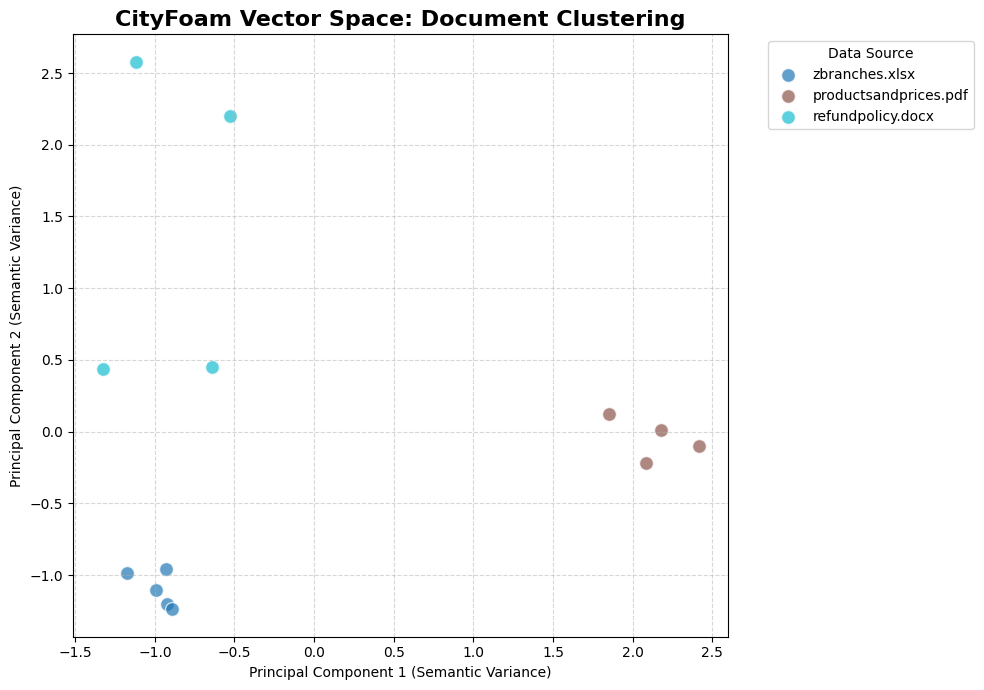

In [6]:
from sklearn.decomposition import PCA
import numpy as np

db_data = collection.get(include=['embeddings', 'metadatas'])
embeddings = np.array(db_data['embeddings'])
sources = [meta.get('source', 'Unknown') for meta in db_data['metadatas']]

# 3. Squash the vectors down to 2D (X and Y coordinates)
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 4. Plot the clusters!
plt.figure(figsize=(10, 7))
unique_sources = list(set(sources))
colors = plt.cm.get_cmap('tab10', len(unique_sources))

for i, source in enumerate(unique_sources):
    # Find all points belonging to this specific file (e.g., catalog vs branches)
    indices = [idx for idx, s in enumerate(sources) if s == source]
    plt.scatter(
        reduced_embeddings[indices, 0], 
        reduced_embeddings[indices, 1], 
        label=source, 
        color=colors(i),
        alpha=0.7,
        s=100,
        edgecolors='w'
    )

plt.title("CityFoam Vector Space: Document Clustering", fontsize=16, fontweight='bold')
plt.xlabel("Principal Component 1 (Semantic Variance)")
plt.ylabel("Principal Component 2 (Semantic Variance)")
plt.legend(title="Data Source", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()